---
title: "Kronecker-multiplicative GP — spatially varying warming rates"
---

# Annual temperature extremes over Spain — part 2: a spatially varying climate response

This is a direct follow-up to [01_spain_extremes](01_spain_extremes.ipynb). Same block-maxima data, same GEV likelihood, same Iberian grid — but we **upgrade $\beta$ from a scalar to a spatial GP**, so each location gets its own warming amplification rate.

The previous notebook fitted

$$\tau(s, t) = \mu(s) + \beta \cdot \bigl(\mathrm{GMST}(t) - \overline{\mathrm{GMST}}\bigr) + \tau_r(t) \qquad \text{(additive / Kronecker-sum GP)}$$

with a **single scalar $\beta$** controlling how quickly every station warms as GMST rises. That's a strong assumption: Madrid, Seville and Bilbao all get the same amplification factor. In reality, continental interiors tend to warm faster than coastal locations, elevation modulates the response, and there are broad synoptic patterns that make some regions more sensitive to global warming than others.

This notebook replaces $\beta$ with a spatial GP $\beta(s)$, giving

$$\tau(s, t) = \mu(s) + \beta(s) \cdot \bigl(\mathrm{GMST}(t) - \overline{\mathrm{GMST}}\bigr) \qquad \text{(multiplicative / Kronecker-product GP)}$$

and drops the temporal residual $\tau_r(t)$ — every temporal deviation is now absorbed into the per-location warming rate. The product $\beta(s) \cdot d(t)$ is a rank-1 space-time interaction, and the prior covariance on the full grid becomes a **sum of two Kronecker products** rather than a Kronecker sum — $K_\mu \otimes J_T + K_\beta \otimes d d^\top$, which we construct as `gaussx.SumKronecker(Kronecker(K_mu, J_T), Kronecker(K_beta, dd_T))`.

## Background — the multiplicative model

### From scalar to field

A scalar amplification $\beta$ has an obvious statistical symptom: residuals cluster spatially. If you fit the nb-01 model and map $(y - \hat\tau)$, locations that warm faster than $\beta$ predicts will show systematically positive residuals in the last decade, and locations that warm slower will show the opposite sign. The correct fix is to let $\beta$ itself vary in space:

- $\mu(s) \sim \mathcal{GP}(0, k_\mu)$ — the **constant spatial residual**. Encodes the time-invariant climate offset of each location (e.g. "Seville is ~4 °C hotter than Bilbao on average").
- $\beta(s) = \beta_0 + \tilde{\beta}(s), \quad \tilde{\beta} \sim \mathcal{GP}(0, k_\beta)$ — the **spatially varying rate**. Controls how strongly each location's extremes respond to global warming. Prior mean $\beta_0 \approx 1$ means "by default, one degree of global warming raises local extremes by one degree".

The combined latent field on a grid $S \times T$ is

$$\tau(s_i, t_j) = \mu(s_i) + \beta(s_i) \cdot d_j, \qquad d_j = \mathrm{GMST}(t_j) - \overline{\mathrm{GMST}},$$

and observations are GEV:

$$y(s_i, t_j) \sim \mathrm{GEV}\bigl(\tau(s_i, t_j),\, \sigma,\, \xi\bigr).$$

### Covariance on the full grid — a sum of two Kronecker products

Since $\mu$ and $\tilde{\beta}$ are a priori independent GPs, the covariance of $\tau$ at any two grid points factorises:

$$\mathrm{cov}\bigl(\tau(s_i, t_j),\, \tau(s_k, t_l)\bigr) = \underbrace{\mathrm{cov}\bigl(\mu(s_i), \mu(s_k)\bigr)}_{\mu \text{ is constant in time}} + \underbrace{d_j \, d_l \cdot \mathrm{cov}\bigl(\tilde{\beta}(s_i), \tilde{\beta}(s_k)\bigr)}_{\tilde{\beta} \text{ scaled by fixed time feature}} = K_\mu[i, k] + d_j \, d_l \cdot K_\beta[i, k].$$

Write the observation grid as a row-major vector (spatial index outer, temporal inner). The full $S \cdot T$ prior covariance is

$$K_\tau \;=\; K_\mu \otimes J_T \;+\; K_\beta \otimes d d^\top, \qquad J_T = \mathbf{1}_T \mathbf{1}_T^\top,$$

— a **sum of two Kronecker products**. Both right-hand factors are rank-1 ($J_T$ and $d d^\top$), so the full covariance is at most rank-$2S$ in the time direction. This is the hallmark of the multiplicative model: **space-time interaction is rank-bounded by the number of latent spatial fields** (here two: $\mu$ and $\tilde{\beta}$).

Contrast with nb 01's additive prior $K_\mu \otimes I_T + I_S \otimes K_t$, which has full-rank temporal identity but forces the **same** time pattern at every location. The multiplicative case trades that rigidity for a fixed temporal basis (the column span of $\mathbf{1}_T$ and $d$) that every location can weight differently.

### Variational family — mean-field across fields

Exactly as in nb 01, the mean-field factorisation matches the prior's independence:

$$q(\mu, \tilde{\beta}) = q_\mu(\mu) \cdot q_\beta(\tilde{\beta}), \qquad q_\mu = \mathcal{N}\!\bigl(m_\mu, L_\mu L_\mu^\top\bigr), \quad q_\beta = \mathcal{N}\!\bigl(m_\beta, L_\beta L_\beta^\top\bigr),$$

both over the $S$ locations (no inducing-point sparsification here — $S = 40$ is small enough to use the full spatial GP directly). The KL decomposes,

$$\mathrm{KL}(q \,\|\, p) = \mathrm{KL}\bigl(q_\mu \,\|\, \mathcal{N}(0, K_\mu)\bigr) + \mathrm{KL}\bigl(q_\beta \,\|\, \mathcal{N}(0, K_\beta)\bigr),$$

and the per-point 1-D marginal $q\bigl(\tau(s_i, t_j)\bigr)$ stays Gaussian,

$$m_\tau(s_i, t_j) = m_\mu(s_i) + \bigl(\beta_0 + m_\beta(s_i)\bigr) \cdot d_j, \qquad v_\tau(s_i, t_j) = v_\mu(s_i) + d_j^{\,2} \cdot v_\beta(s_i).$$

That's all `gaussx.GaussHermiteIntegrator` needs to compute $\mathbb{E}_q[\log \mathrm{GEV}(y \mid \tau, \sigma, \xi)]$ pointwise. No cross-term because $q$ factorises between $\mu$ and $\tilde{\beta}$.

### Identifiability

Two potential traps:

1. **$\mu(s)$ vs $\beta(s)$ at $d = 0$.** At any year $t^*$ where $\mathrm{GMST}(t^*) = \overline{\mathrm{GMST}}$, $\beta(s) \cdot 0 = 0$ and the likelihood only sees $\mu(s)$. Centering $d$ around its sample mean (as we do) spreads the information about $\beta(s)$ over the whole 40-year range, so there's no single time with $d = 0$ — but the years closest to mean GMST contribute least to $\beta$ identification. A short record would amplify this problem.
2. **$\beta_0$ vs mean of $\tilde{\beta}$.** The prior on $\tilde{\beta}$ is zero-mean, but nothing stops the variational posterior mean $\overline{m_\beta}$ from drifting if $\beta_0$ is also trainable. We keep $\beta_0$ trainable for realism but regularise via the zero-mean prior on $\tilde{\beta}$ — which gently pulls $\overline{m_\beta}$ toward zero at optimum.

## Setup

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import lineax as lx
import numpyro.distributions as nd
from numpyro.distributions import constraints
from jaxtyping import Array, Float
from scipy.stats import genextreme

import gaussx
from pyrox.gp._src.kernels import matern_kernel, rbf_kernel

jax.config.update("jax_enable_x64", True)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic data — a warming Spain with heterogeneous response

Stations and GMST are identical to nb 01 so that the two notebooks can be compared directly.

In [2]:
SPAIN_BBOX = (-9.5, 3.5, 36.0, 43.8)  # lon_min, lon_max, lat_min, lat_max


def _on_land(lon: Float[Array, " N"], lat: Float[Array, " N"]) -> Float[Array, " N"]:
    west_of_galicia = (lon < -8.8) & (lat > 42.3)
    below_africa = lat < 36.2
    east_mediterranean = (lon > 2.5) & (lat < 39.0)
    return ~(west_of_galicia | below_africa | east_mediterranean)


def _sample_stations(key: jr.PRNGKey, n_target: int) -> Float[Array, "n 2"]:
    candidates = jr.uniform(
        key,
        (n_target * 4, 2),
        minval=jnp.array([SPAIN_BBOX[0], SPAIN_BBOX[2]]),
        maxval=jnp.array([SPAIN_BBOX[1], SPAIN_BBOX[3]]),
    )
    mask = _on_land(candidates[:, 0], candidates[:, 1])
    return candidates[mask][:n_target]


S = 40
T = 40
YEAR_0 = 1985
YEARS = jnp.arange(YEAR_0, YEAR_0 + T)

key = jr.PRNGKey(2024)
key, key_stations = jr.split(key)
stations = _sample_stations(key_stations, S)
lon_st = stations[:, 0]
lat_st = stations[:, 1]

### GMST proxy — linear trend + AR(1) red noise (same as nb 01)

In [3]:
def synthetic_gmst(years: Float[Array, " T"], key: jr.PRNGKey) -> Float[Array, " T"]:
    t_norm = (years - years[0]) / jnp.maximum(years[-1] - years[0], 1)
    trend = 0.1 + 0.8 * t_norm
    alpha = 0.6
    white = 0.05 * jr.normal(key, (years.shape[0],))

    def step(prev, eps):
        cur = alpha * prev + eps
        return cur, cur

    _, red = jax.lax.scan(step, white[0], white[1:])
    noise = jnp.concatenate([white[:1], red])
    return trend + noise


key, key_gmst = jr.split(key)
gmst = synthetic_gmst(YEARS, key_gmst)
gmst_centred = gmst - jnp.mean(gmst)
d_vec = gmst_centred  # clearer variable name for equations below
print(f"GMST range:  {float(gmst[0]):.2f}  ->  {float(gmst[-1]):.2f} °C")
print(f"d range:     {float(d_vec.min()):+.2f}  ->  {float(d_vec.max()):+.2f} °C (centred)")

GMST range:  0.02  ->  0.85 °C
d range:     -0.46  ->  +0.37 °C (centred)


### Ground-truth $\beta^*(s)$ drawn from a Matern GP

Rather than a deterministic pattern, we draw $\beta^*(s)$ from a spatial GP with a known kernel so that the GP prior is a well-specified model of the truth. This is the honest thing to do when the inference procedure itself uses a GP prior on $\tilde{\beta}(s)$ — any deterministic pattern (a pure latitude gradient, for instance) would give misleadingly good recovery under a mis-specified model and misleadingly bad recovery under an over-regularised one.

Prior mean $\beta_0^* = 1.2$ (most of Spain warms slightly faster than GMST); fluctuations come from a zero-mean Matern-3/2 kernel with variance $0.25$ and lengthscale $3°$ (~330 km). Expected $2\sigma$ range of $\beta^*(s)$ is roughly $[0.2, 2.2]$.

In [4]:
def _rbf_gram(X1, X2, var, ls):
    return rbf_kernel(X1, X2, jnp.asarray(var), jnp.asarray(ls))


def _matern32_gram(X1, X2, var, ls):
    return matern_kernel(X1, X2, jnp.asarray(var), jnp.asarray(ls), nu=1.5)


def draw_from_gp(K: Float[Array, "N N"], key: jr.PRNGKey, jitter: float = 1e-4) -> Float[Array, " N"]:
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))
    return L @ jr.normal(key, (K.shape[0],))


TRUTH = {
    "mu0": 35.0,
    "k_s_var": 4.0,
    "k_s_ls": 2.0,
    "k_beta_var": 0.25,
    "k_beta_ls": 3.0,
    "beta0": 1.2,
    "gev_sigma": 1.8,
    "gev_xi": 0.12,
}

K_s_truth = _matern32_gram(stations, stations, TRUTH["k_s_var"], TRUTH["k_s_ls"])
K_beta_truth = _matern32_gram(stations, stations, TRUTH["k_beta_var"], TRUTH["k_beta_ls"])

key, key_mu, key_beta = jr.split(key, 3)
mu_truth = draw_from_gp(K_s_truth, key_mu)
beta_truth = TRUTH["beta0"] + draw_from_gp(K_beta_truth, key_beta)

print(f"beta*(s) range:  {float(beta_truth.min()):.2f}  ->  {float(beta_truth.max()):.2f}")
print(f"beta*(s) mean:   {float(beta_truth.mean()):.2f}   (truth beta0 = {TRUTH['beta0']:.2f})")

# Latent field: tau*(s, t) = mu0 + mu*(s) + beta*(s) * d(t)
f_truth = TRUTH["mu0"] + mu_truth[:, None] + beta_truth[:, None] * d_vec[None, :]  # (S, T)

beta*(s) range:  -0.02  ->  2.85
beta*(s) mean:   1.23   (truth beta0 = 1.20)


### GEV observation model (verbatim from nb 01)

A 40-line `numpyro.distributions.Distribution` subclass — see nb 01 for the derivation and the $\xi \to 0$ limit handling.

In [5]:
class GeneralizedExtremeValue(nd.Distribution):
    arg_constraints = {
        "loc": constraints.real,
        "scale": constraints.positive,
        "shape": constraints.real,
    }
    support = constraints.real
    reparametrized_params = ["loc", "scale"]

    def __init__(self, loc, scale, shape, *, validate_args=None):
        self.loc = jnp.asarray(loc)
        self.scale = jnp.asarray(scale)
        self.shape = jnp.asarray(shape)
        batch_shape = jax.lax.broadcast_shapes(
            jnp.shape(self.loc), jnp.shape(self.scale), jnp.shape(self.shape)
        )
        super().__init__(batch_shape=batch_shape, validate_args=validate_args)

    def log_prob(self, value):
        z = (value - self.loc) / self.scale
        small_xi = jnp.abs(self.shape) < 1e-6
        safe_shape = jnp.where(small_xi, 1.0, self.shape)
        arg = 1.0 + safe_shape * z
        safe_arg = jnp.where(arg > 0, arg, 1.0)
        t = safe_arg ** (-1.0 / safe_shape)
        gev_lp = -jnp.log(self.scale) - (1.0 + 1.0 / safe_shape) * jnp.log(safe_arg) - t
        gev_lp = jnp.where(arg > 0, gev_lp, -jnp.inf)
        gumbel_lp = -jnp.log(self.scale) - z - jnp.exp(-z)
        return jnp.where(small_xi, gumbel_lp, gev_lp)

    def sample(self, key, sample_shape=()):
        u = jr.uniform(key, sample_shape + self.batch_shape, minval=1e-12, maxval=1.0)
        small_xi = jnp.abs(self.shape) < 1e-6
        safe_shape = jnp.where(small_xi, 1.0, self.shape)
        gev_draw = self.loc + self.scale * ((-jnp.log(u)) ** (-safe_shape) - 1.0) / safe_shape
        gumbel_draw = self.loc - self.scale * jnp.log(-jnp.log(u))
        return jnp.where(small_xi, gumbel_draw, gev_draw)


# Sanity-check vs scipy (same values as nb 01, included for self-containedness)
y_grid = jnp.linspace(-2.0, 25.0, 60)
ours = GeneralizedExtremeValue(3.0, 1.5, 0.2).log_prob(y_grid)
theirs = genextreme.logpdf(np.asarray(y_grid), c=-0.2, loc=3.0, scale=1.5)
print(f"GEV vs scipy (xi=0.2)  max |diff|  = {float(jnp.max(jnp.abs(ours - theirs))):.2e}")

GEV vs scipy (xi=0.2)  max |diff|  = 1.14e-13


### Draw the observations

In [6]:
key, key_obs = jr.split(key)
y_obs = GeneralizedExtremeValue(
    loc=f_truth, scale=TRUTH["gev_sigma"], shape=TRUTH["gev_xi"]
).sample(key_obs)
print(f"y_obs shape: {y_obs.shape}  range: [{float(y_obs.min()):.1f}, {float(y_obs.max()):.1f}] °C")

y_obs shape: (40, 40)  range: [28.2, 57.6] °C


### Inspecting the truth

Three panels: (a) ground-truth spatial offset $\mu^*(s)$ — what nb 01 also had; (b) **the new ingredient** — ground-truth amplification $\beta^*(s)$; (c) yearly-max timeseries at four stations picked from the low-$\beta$ / high-$\beta$ ends of the $\beta^*(s)$ field to show the differential slopes.

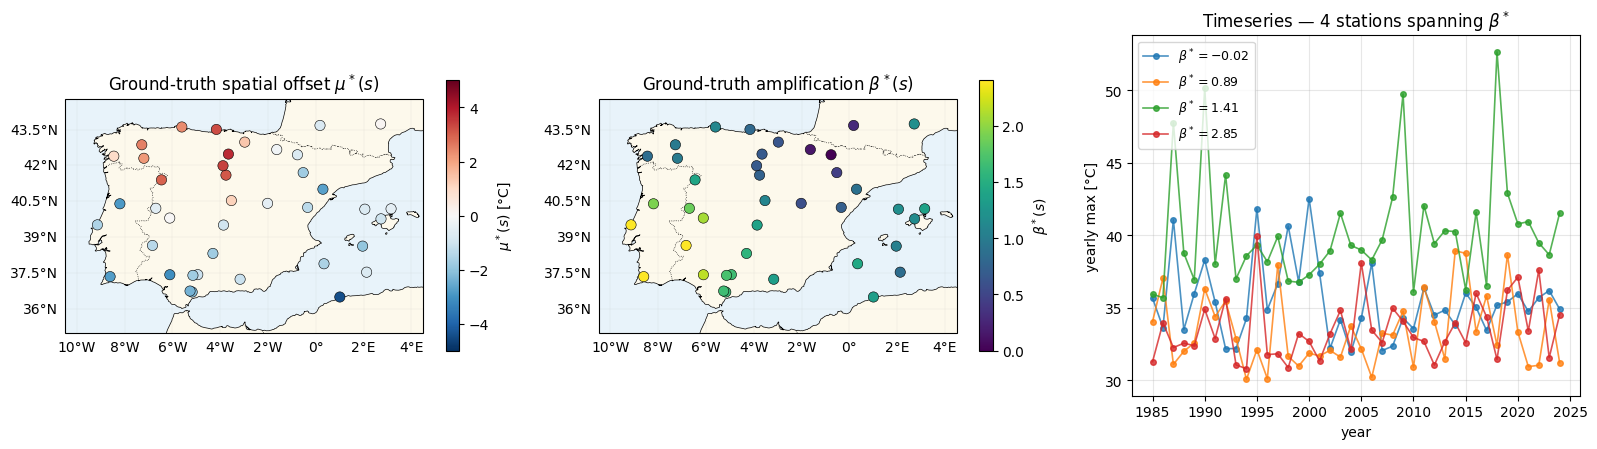

In [7]:
def plot_stations(ax, values, *, cmap: str, vlim: tuple, label: str) -> None:
    ax.set_extent(
        [SPAIN_BBOX[0] - 1, SPAIN_BBOX[1] + 1, SPAIN_BBOX[2] - 1, SPAIN_BBOX[3] + 1],
        crs=ccrs.PlateCarree(),
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f3fa")
    ax.add_feature(cfeature.LAND, facecolor="#fdf9ec")
    sc = ax.scatter(
        np.asarray(lon_st), np.asarray(lat_st),
        c=np.asarray(values), cmap=cmap, vmin=vlim[0], vmax=vlim[1],
        s=55, edgecolors="k", linewidths=0.4,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(sc, ax=ax, shrink=0.75, label=label)


fig = plt.figure(figsize=(16, 4.6))
ax_mu = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree())
plot_stations(ax_mu, mu_truth, cmap="RdBu_r", vlim=(-5, 5), label=r"$\mu^*(s)$ [°C]")
ax_mu.set_title(r"Ground-truth spatial offset $\mu^*(s)$")

ax_beta = fig.add_subplot(1, 3, 2, projection=ccrs.PlateCarree())
plot_stations(ax_beta, beta_truth, cmap="viridis", vlim=(0.0, 2.4), label=r"$\beta^*(s)$")
ax_beta.set_title(r"Ground-truth amplification $\beta^*(s)$")

# Timeseries panel — pick two low-beta and two high-beta stations
order_beta = jnp.argsort(beta_truth)
picks = jnp.array([order_beta[0], order_beta[S // 3], order_beta[2 * S // 3], order_beta[-1]])
ax_ts = fig.add_subplot(1, 3, 3)
for s in picks:
    s_i = int(s)
    ax_ts.plot(
        YEARS, y_obs[s_i, :], "o-", lw=1.2, ms=4, alpha=0.8,
        label=rf"$\beta^*={float(beta_truth[s_i]):.2f}$",
    )
ax_ts.set_xlabel("year")
ax_ts.set_ylabel("yearly max [°C]")
ax_ts.set_title(r"Timeseries — 4 stations spanning $\beta^*$")
ax_ts.legend(loc="upper left", fontsize=9)
ax_ts.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The middle panel shows the target of this notebook: recovering $\beta^*(s)$ from data. The rightmost panel shows why it is recoverable — the per-station slopes differ measurably across the $\beta^*$ range.

## Kernel + variational factor classes

Same pattern-A eqx modules as every other notebook in this series; see nb 01 for rationale.

In [8]:
class MaternLite(eqx.Module):
    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance=1.0, lengthscale=1.0):
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    def __call__(self, X1, X2):
        return matern_kernel(
            X1, X2, jnp.exp(self.log_variance), jnp.exp(self.log_lengthscale), nu=1.5
        )


def _tril(L: Float[Array, "N N"]) -> Float[Array, "N N"]:
    tri = jnp.tril(L, k=-1)
    diag = jax.nn.softplus(jnp.diag(L))
    return tri + jnp.diag(diag)


class VariationalFactor(eqx.Module):
    mean: Float[Array, " N"]
    raw_L: Float[Array, "N N"]

    @classmethod
    def init(cls, n: int, scale: float = 0.3) -> "VariationalFactor":
        raw_L = jnp.eye(n) * jnp.log(jnp.expm1(jnp.asarray(scale)))
        return cls(mean=jnp.zeros(n), raw_L=raw_L)

    @property
    def L(self):
        return _tril(self.raw_L)

    @property
    def cov(self):
        L = self.L
        return L @ L.T

    @property
    def variance_diag(self):
        L = self.L
        return jnp.sum(L * L, axis=-1)

## The multiplicative prior covariance as a `gaussx.SumKronecker`

Before setting up training, let's assemble the full-grid prior covariance with gaussx operators and inspect its storage cost. This is purely pedagogical — we never materialise it during training (the two spatial factorised KLs below sidestep it entirely), but it makes the multiplicative Kronecker structure explicit.

In [9]:
k_s_demo = MaternLite.init(variance=2.0, lengthscale=2.0)
k_beta_demo = MaternLite.init(variance=0.2, lengthscale=3.0)

K_s0 = k_s_demo(stations, stations)
K_beta0 = k_beta_demo(stations, stations)

J_t = jnp.ones((T, T))          # all-ones time factor for the mu(s) block (constant in time)
dd_t = jnp.outer(d_vec, d_vec)  # rank-1 time factor for the beta(s) * d(t) block

op_Ks = lx.MatrixLinearOperator(K_s0, lx.positive_semidefinite_tag)
op_Jt = lx.MatrixLinearOperator(J_t, lx.positive_semidefinite_tag)
op_Kb = lx.MatrixLinearOperator(K_beta0, lx.positive_semidefinite_tag)
op_dd = lx.MatrixLinearOperator(dd_t, lx.positive_semidefinite_tag)

K_mu_full = gaussx.Kronecker(op_Ks, op_Jt)    # K_mu  (x) J_T
K_beta_full = gaussx.Kronecker(op_Kb, op_dd)  # K_beta (x) dd^T
K_tau = gaussx.SumKronecker(K_mu_full, K_beta_full)

print(f"prior operator:   {type(K_tau).__name__}")
print(f"  logical shape:  ({K_tau.in_size()}, {K_tau.in_size()})  = ({S}·{T}, {S}·{T})")
print(f"  storage cost:   {2 * (S * S + T * T)} entries "
      f"(vs {(S * T) ** 2} dense, {(S * T) ** 2 / (2 * (S * S + T * T)):.0f}× compression)")
print("  time-rank:      1 + 1 = 2  (J_T and dd^T each rank 1)")

prior operator:   SumKronecker
  logical shape:  (1600, 1600)  = (40·40, 40·40)
  storage cost:   6400 entries (vs 2560000 dense, 400× compression)
  time-rank:      1 + 1 = 2  (J_T and dd^T each rank 1)


The time rank is 2 — every location shares the same two temporal basis functions (constant + GMST anomaly), just with location-dependent weights $m_\mu(s)$ and $m_\beta(s) + \beta_0$. That low time-rank is precisely what lets this model fit $ST = 1600$ observations with only $2S = 80$ spatial latent values.

## Model

Two spatial variational factors, shared Matern-3/2 kernel family, trainable $\beta_0$ scalar. GEV scale $\sigma$ is stored in log space for positivity; shape $\xi$ is unconstrained.

In [10]:
class Model(eqx.Module):
    k_mu: MaternLite
    k_beta: MaternLite
    q_mu: VariationalFactor       # q(mu(s))
    q_beta: VariationalFactor     # q(beta_tilde(s)) — zero-mean prior, trainable posterior mean
    mu0: Float[Array, ""]
    beta0: Float[Array, ""]       # prior-mean intercept of beta; trainable scalar
    log_sigma: Float[Array, ""]
    xi: Float[Array, ""]
    jitter: float = eqx.field(static=True, default=1e-4)

    @classmethod
    def init(
        cls,
        S: int,
        *,
        mu0_init: float = 30.0,
        beta0_init: float = 1.0,
        sigma_init: float = 2.0,
        xi_init: float = 0.05,
    ) -> "Model":
        return cls(
            k_mu=MaternLite.init(variance=1.0, lengthscale=3.0),
            k_beta=MaternLite.init(variance=0.2, lengthscale=3.0),
            q_mu=VariationalFactor.init(S, scale=0.5),
            q_beta=VariationalFactor.init(S, scale=0.3),
            mu0=jnp.asarray(mu0_init),
            beta0=jnp.asarray(beta0_init),
            log_sigma=jnp.log(jnp.asarray(sigma_init)),
            xi=jnp.asarray(xi_init),
        )

    def K_mu(self, X_s):
        K = self.k_mu(X_s, X_s) + self.jitter * jnp.eye(X_s.shape[0])
        return lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)

    def K_beta(self, X_s):
        K = self.k_beta(X_s, X_s) + self.jitter * jnp.eye(X_s.shape[0])
        return lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)

## ELBO

Identical pattern to nb 01, now with **two** spatial KLs instead of (spatial KL + temporal KL).

In [11]:
def kl_factor(q: VariationalFactor, K_prior_op: lx.AbstractLinearOperator):
    zeros = jnp.zeros_like(q.mean)
    q_cov = lx.MatrixLinearOperator(q.cov, lx.positive_semidefinite_tag)
    return gaussx.dist_kl_divergence(q.mean, q_cov, zeros, K_prior_op)


_GH = gaussx.GaussHermiteIntegrator(order=20)


def ell_point(mean, var, y, log_sigma, xi):
    r"""$\mathbb{E}_{q(\tau)}[\log \mathrm{GEV}(y \mid \tau, \sigma, \xi)]$ for one $(s, t)$."""
    state = gaussx.GaussianState(
        mean=mean[None],
        cov=lx.MatrixLinearOperator(var[None, None], lx.positive_semidefinite_tag),
    )

    def log_lik(f):
        return GeneralizedExtremeValue(loc=f[0], scale=jnp.exp(log_sigma), shape=xi).log_prob(y)

    return gaussx.log_likelihood_expectation(log_lik, state, _GH)


def total_ell(
    model: Model,
    d_vec: Float[Array, " T"],
    y: Float[Array, "S T"],
) -> Float[Array, ""]:
    m_mu = model.q_mu.mean                         # (S,)
    m_beta = model.q_beta.mean                     # (S,) — variational mean of beta_tilde
    v_mu = model.q_mu.variance_diag                # (S,)
    v_beta = model.q_beta.variance_diag            # (S,)
    # m_tau(s,t) = mu0 + m_mu(s) + (beta0 + m_beta_tilde(s)) * d(t)
    # v_tau(s,t) = v_mu(s) + d(t)^2 * v_beta_tilde(s)
    beta_total_s = model.beta0 + m_beta            # (S,)
    mean_grid = model.mu0 + m_mu[:, None] + beta_total_s[:, None] * d_vec[None, :]
    var_grid = v_mu[:, None] + v_beta[:, None] * (d_vec ** 2)[None, :]
    ell_vmapped = jax.vmap(
        jax.vmap(ell_point, in_axes=(0, 0, 0, None, None)),
        in_axes=(0, 0, 0, None, None),
    )
    return jnp.sum(ell_vmapped(mean_grid, var_grid, y, model.log_sigma, model.xi))


def neg_elbo(
    model: Model,
    X_s: Float[Array, "S 2"],
    d_vec: Float[Array, " T"],
    y: Float[Array, "S T"],
) -> Float[Array, ""]:
    K_mu_op = model.K_mu(X_s)
    K_beta_op = model.K_beta(X_s)
    kl = kl_factor(model.q_mu, K_mu_op) + kl_factor(model.q_beta, K_beta_op)
    ell = total_ell(model, d_vec, y)
    return kl - ell

## Training

In [12]:
model = Model.init(
    S=S,
    mu0_init=float(jnp.mean(y_obs)),
    beta0_init=1.0,
    sigma_init=2.0,
    xi_init=0.05,
)
optimiser = optax.chain(optax.clip_by_global_norm(5.0), optax.adam(1e-2))
opt_state = optimiser.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(model, opt_state):
    loss, grads = eqx.filter_value_and_grad(neg_elbo)(model, stations, d_vec, y_obs)
    updates, opt_state = optimiser.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss


n_steps = 2500
losses: list[float] = []
for _ in range(n_steps):
    model, opt_state, loss = train_step(model, opt_state)
    losses.append(float(loss))

beta_post = model.beta0 + model.q_beta.mean  # (S,)
print(f"final -ELBO         = {losses[-1]:.2f}")
print(f"fitted mu0          = {float(model.mu0):.2f}     (truth {TRUTH['mu0']:.2f})")
print(f"fitted beta0        = {float(model.beta0):.3f}    (truth mean beta* {float(beta_truth.mean()):.3f})")
print(f"fitted beta(s) rng  = [{float(beta_post.min()):.2f}, {float(beta_post.max()):.2f}]"
      f"   (truth [{float(beta_truth.min()):.2f}, {float(beta_truth.max()):.2f}])")
print(f"fitted sigma (GEV)  = {float(jnp.exp(model.log_sigma)):.3f}   (truth {TRUTH['gev_sigma']:.3f})")
print(f"fitted xi (GEV)     = {float(model.xi):.3f}     (truth {TRUTH['gev_xi']:.3f})")
print(f"fitted k_mu ls      = {float(jnp.exp(model.k_mu.log_lengthscale)):.2f} deg  "
      f"(truth {TRUTH['k_s_ls']:.2f} deg)")
print(f"fitted k_beta ls    = {float(jnp.exp(model.k_beta.log_lengthscale)):.2f} deg  "
      f"(truth {TRUTH['k_beta_ls']:.2f} deg)")

final -ELBO         = 3614.97
fitted mu0          = 34.29     (truth 35.00)
fitted beta0        = 1.412    (truth mean beta* 1.235)
fitted beta(s) rng  = [0.93, 1.74]   (truth [-0.02, 2.85])
fitted sigma (GEV)  = 1.766   (truth 1.800)
fitted xi (GEV)     = 0.130     (truth 0.120)
fitted k_mu ls      = 1.85 deg  (truth 2.00 deg)
fitted k_beta ls    = 2.78 deg  (truth 3.00 deg)


### Loss curve

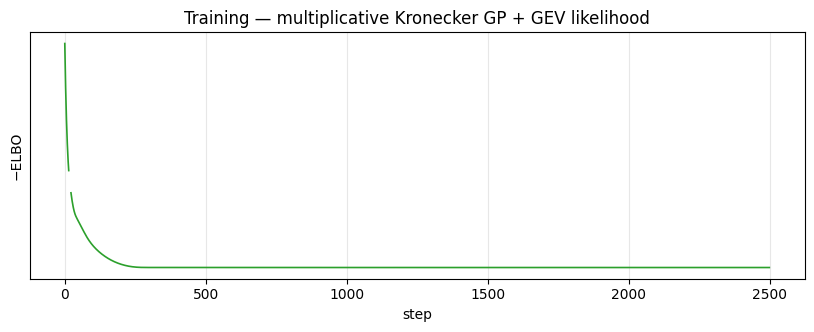

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(losses, "C2-", lw=1.2)
ax.set_xlabel("step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("Training — multiplicative Kronecker GP + GEV likelihood")
ax.grid(alpha=0.3, which="both")
plt.show()

## Parameter recovery

The headline plot is the $\beta(s)$ map: can the model recover a smoothly-varying warming rate from 40 stations × 40 years of GEV-distributed maxima?

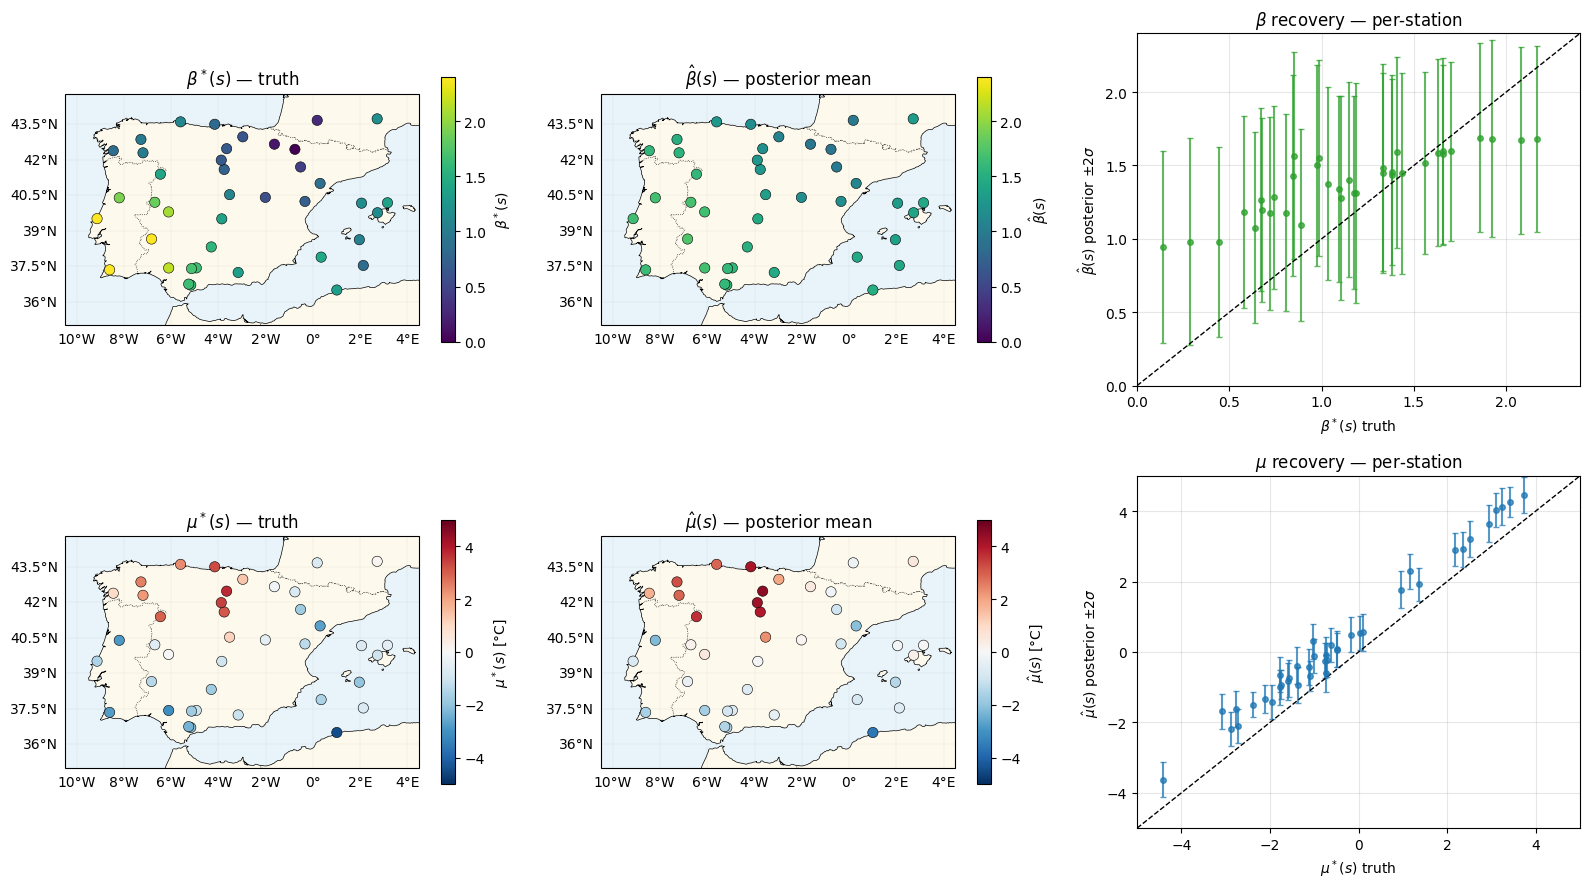

In [14]:
beta_mean = model.beta0 + model.q_beta.mean       # (S,)
beta_std = jnp.sqrt(model.q_beta.variance_diag)    # (S,) — std of beta_tilde == std of beta
mu_mean = model.q_mu.mean
mu_std = jnp.sqrt(model.q_mu.variance_diag)

# Colour scales matched between truth and posterior maps
vlim_beta = (0.0, 2.4)
vlim_mu = (-5.0, 5.0)

fig = plt.figure(figsize=(16, 9))
# row 1 — beta(s)
ax = fig.add_subplot(2, 3, 1, projection=ccrs.PlateCarree())
plot_stations(ax, beta_truth, cmap="viridis", vlim=vlim_beta, label=r"$\beta^*(s)$")
ax.set_title(r"$\beta^*(s)$ — truth")

ax = fig.add_subplot(2, 3, 2, projection=ccrs.PlateCarree())
plot_stations(ax, beta_mean, cmap="viridis", vlim=vlim_beta, label=r"$\hat\beta(s)$")
ax.set_title(r"$\hat\beta(s)$ — posterior mean")

ax = fig.add_subplot(2, 3, 3)
ax.errorbar(
    np.asarray(beta_truth), np.asarray(beta_mean), yerr=2 * np.asarray(beta_std),
    fmt="o", color="C2", ms=4, alpha=0.75, capsize=2,
)
lo, hi = vlim_beta
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(r"$\beta^*(s)$ truth")
ax.set_ylabel(r"$\hat\beta(s)$ posterior $\pm 2\sigma$")
ax.set_title(r"$\beta$ recovery — per-station")
ax.grid(alpha=0.3)

# row 2 — mu(s)
ax = fig.add_subplot(2, 3, 4, projection=ccrs.PlateCarree())
plot_stations(ax, mu_truth, cmap="RdBu_r", vlim=vlim_mu, label=r"$\mu^*(s)$ [°C]")
ax.set_title(r"$\mu^*(s)$ — truth")

ax = fig.add_subplot(2, 3, 5, projection=ccrs.PlateCarree())
plot_stations(ax, mu_mean, cmap="RdBu_r", vlim=vlim_mu, label=r"$\hat\mu(s)$ [°C]")
ax.set_title(r"$\hat\mu(s)$ — posterior mean")

ax = fig.add_subplot(2, 3, 6)
ax.errorbar(
    np.asarray(mu_truth), np.asarray(mu_mean), yerr=2 * np.asarray(mu_std),
    fmt="o", color="C0", ms=4, alpha=0.75, capsize=2,
)
lo, hi = vlim_mu
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(r"$\mu^*(s)$ truth")
ax.set_ylabel(r"$\hat\mu(s)$ posterior $\pm 2\sigma$")
ax.set_title(r"$\mu$ recovery — per-station")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### GEV tail recovery

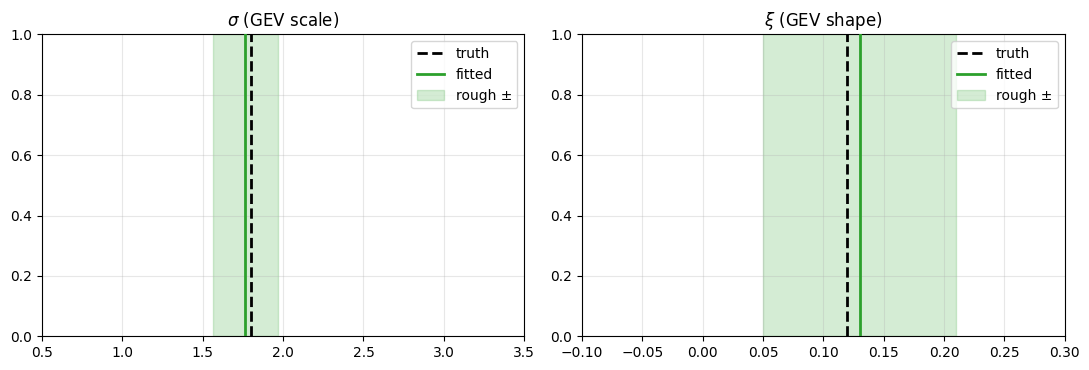

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, truth_val, fit_val, unc, xr) in zip(
    axes,
    [
        (r"$\sigma$ (GEV scale)", TRUTH["gev_sigma"], float(jnp.exp(model.log_sigma)), 0.2, (0.5, 3.5)),
        (r"$\xi$ (GEV shape)", TRUTH["gev_xi"], float(model.xi), 0.08, (-0.1, 0.3)),
    ],
    strict=True,
):
    ax.axvline(truth_val, color="k", ls="--", lw=2, label="truth", zorder=2)
    ax.axvline(fit_val, color="C2", lw=2, label="fitted", zorder=3)
    ax.axvspan(fit_val - unc, fit_val + unc, color="C2", alpha=0.2, label="rough ±")
    ax.set_xlim(*xr)
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Return-level maps — now spatially varying

The return level at a prospective year $t^*$ is

$$\hat\tau(s, t^*) = \mu_0 + m_\mu(s) + \hat\beta(s) \cdot d(t^*),$$

$$z_p(s, t^*) = \hat\tau(s, t^*) + \frac{\hat\sigma}{\hat\xi}\Bigl\{\bigl[-\log(1 - p)\bigr]^{-\hat\xi} - 1\Bigr\}.$$

Because $\hat\beta(s)$ is now location-dependent, the **spatial pattern of the 2024 $\to$ 2050 warming shift is non-uniform**: high-$\beta$ locations warm faster than low-$\beta$ ones. This is the key qualitative difference from nb 01, where every location shifted by the same amount.

GMST 2024 = 0.848 °C, GMST 2050 (extrap) = 1.398 °C
100-yr return shift 2024->2050:  mean 0.77 °C,  range [0.51, 0.95] °C
  (spatial spread is new; nb 01 had zero spread here)


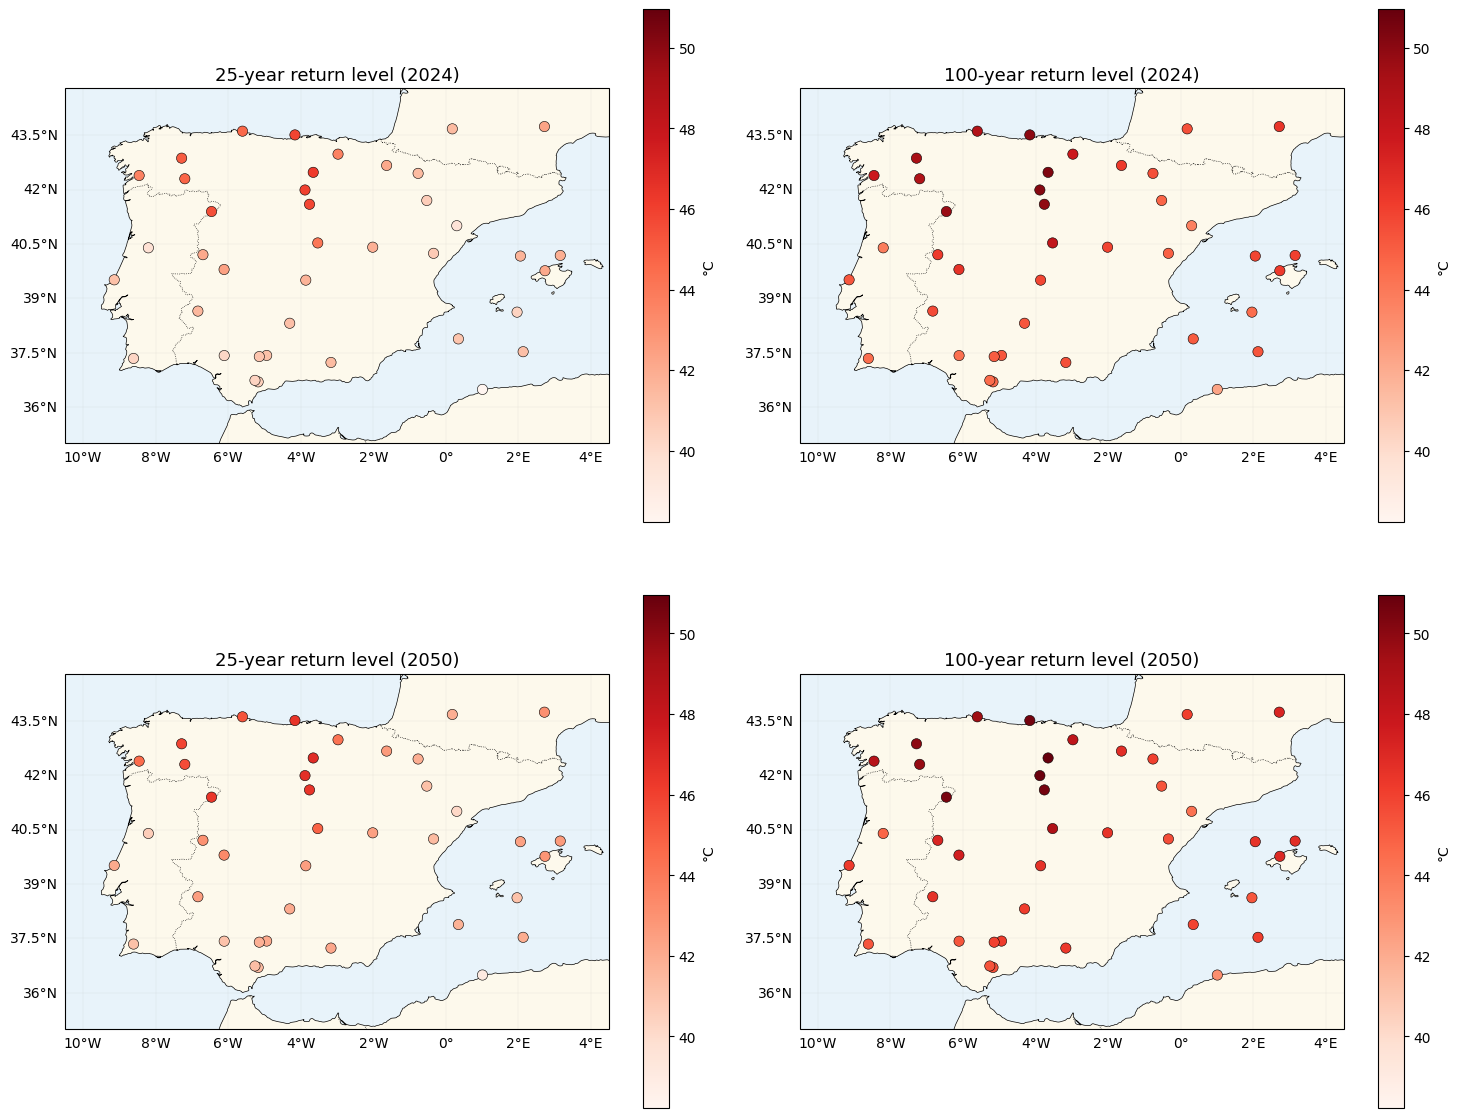

In [16]:
def gev_return_level(mu_loc, sigma, xi, return_period):
    p = 1.0 / return_period
    safe_xi = jnp.where(jnp.abs(xi) < 1e-6, 1.0, xi)
    gev_q = mu_loc + sigma * ((-jnp.log1p(-p)) ** (-safe_xi) - 1.0) / safe_xi
    gumbel_q = mu_loc - sigma * jnp.log(-jnp.log1p(-p))
    return jnp.where(jnp.abs(xi) < 1e-6, gumbel_q, gev_q)


def predictive_tau(model: Model, gmst_star: Float[Array, ""]) -> Float[Array, " S"]:
    r"""$\hat\tau(s, t^*) = \mu_0 + m_\mu(s) + \hat\beta(s) \cdot (\mathrm{GMST}^* - \overline{\mathrm{GMST}})$."""
    d_star = gmst_star - jnp.mean(gmst)
    beta_s = model.beta0 + model.q_beta.mean
    return model.mu0 + model.q_mu.mean + beta_s * d_star


gmst_2024 = gmst[-1]
gmst_trend_per_year = (gmst[-1] - gmst[0]) / (T - 1)
gmst_2050 = gmst_2024 + gmst_trend_per_year * (2050 - (YEAR_0 + T - 1))

tau_2024 = predictive_tau(model, gmst_2024)
tau_2050 = predictive_tau(model, gmst_2050)

sigma_fit = jnp.exp(model.log_sigma)
xi_fit = model.xi

z25_2024 = gev_return_level(tau_2024, sigma_fit, xi_fit, 25)
z100_2024 = gev_return_level(tau_2024, sigma_fit, xi_fit, 100)
z25_2050 = gev_return_level(tau_2050, sigma_fit, xi_fit, 25)
z100_2050 = gev_return_level(tau_2050, sigma_fit, xi_fit, 100)
shift_100 = z100_2050 - z100_2024

vmin = float(jnp.min(jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])))
vmax = float(jnp.max(jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])))
print(f"GMST 2024 = {float(gmst_2024):.3f} °C, GMST 2050 (extrap) = {float(gmst_2050):.3f} °C")
print(f"100-yr return shift 2024->2050:  mean {float(jnp.mean(shift_100)):.2f} °C,  "
      f"range [{float(shift_100.min()):.2f}, {float(shift_100.max()):.2f}] °C")
print("  (spatial spread is new; nb 01 had zero spread here)")

fig, axes = plt.subplots(2, 2, figsize=(15, 13), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, values, title in zip(
    axes.flat,
    [z25_2024, z100_2024, z25_2050, z100_2050],
    ["25-year return level (2024)", "100-year return level (2024)",
     "25-year return level (2050)", "100-year return level (2050)"],
    strict=True,
):
    plot_stations(ax, values, cmap="Reds", vlim=(vmin, vmax), label="°C")
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

### The spatial pattern of warming

Plot $z_{100}(2050) - z_{100}(2024)$ directly. Under the additive model (nb 01) this would be a constant map. Here it tracks $\hat\beta(s)$: locations with high $\hat\beta$ see larger 100-year shifts.

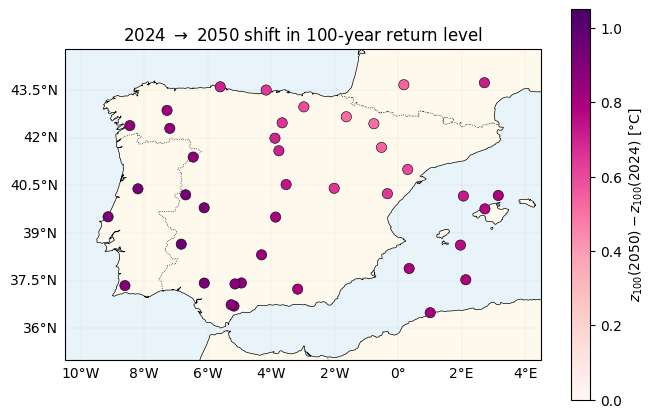

In [17]:
shift_abs = float(jnp.max(jnp.abs(shift_100)))
fig, ax = plt.subplots(figsize=(6.8, 5.5), subplot_kw={"projection": ccrs.PlateCarree()})
plot_stations(
    ax, shift_100, cmap="RdPu", vlim=(0.0, 1.1 * shift_abs),
    label=r"$z_{100}(2050) - z_{100}(2024)$ [°C]",
)
ax.set_title(r"2024 $\to$ 2050 shift in 100-year return level")
plt.tight_layout()
plt.show()

## Contrast with the additive model (nb 01)

| Aspect | Additive (nb 01)                        | Multiplicative (this nb)                   |
|---|---|---|
| Temporal structure | $\beta \cdot d(t) + \tau_r(t)$, one $\beta$ for all stations | $\beta(s) \cdot d(t)$, per-station rate  |
| Prior covariance   | $K_\mu \otimes I_T + I_S \otimes K_t$ (`gaussx.KroneckerSum`) | $K_\mu \otimes J_T + K_\beta \otimes dd^\top$ (`gaussx.SumKronecker`) |
| Time rank          | full ($T$)                              | 2                                          |
| Latent dimension   | $S + T$                                 | $2S$                                       |
| 2050 warming map   | constant                                | spatially varying                          |
| Variational family | $q_\mu(s) \cdot q_{\tau_r}(t)$ — space × time | $q_\mu(s) \cdot q_\beta(s)$ — space × space |

The "Kronecker" in both notebooks refers to the Kronecker-product structure of the prior covariance; the distinction is whether the two factor kernels are combined **additively** ($\oplus$, via `KroneckerSum`) or **multiplicatively** ($\otimes$, via `Kronecker` — stacked inside `SumKronecker` here because we have two rank-1 time factors to sum). Once you've seen the additive case, the multiplicative case reuses every piece of machinery — same kernel modules, same variational factors, same Gauss–Hermite ELL, same closed-form KL — with only the model's definition of $\tau(s, t)$ and the identity of the second spatial GP changing.

## Summary

- `gaussx.SumKronecker(Kronecker(K_mu, J_T), Kronecker(K_beta, dd_T))` is the natural operator for a two-component multiplicative GP prior on an $S \times T$ grid.
- Because $d(t) = \mathrm{GMST}(t) - \overline{\mathrm{GMST}}$ is a **known** covariate, the time factors $J_T$ and $d d^\top$ are rank-1, so the prior's time-rank is 2 — much cheaper than a full $K_s \otimes K_t$ product with a learnt temporal kernel.
- Variational factorisation stays mean-field across GPs (now $q_\mu \cdot q_\beta$), KL splits into two spatial GP KLs, and the Gauss–Hermite ELL needs only the 1-D marginal $q(\tau(s, t))$ — the variance terms $v_\mu(s) + d(t)^2 \cdot v_\beta(s)$ correctly account for the GMST-magnified uncertainty in $\beta(s)$ at extreme GMST years.
- On the return-level maps, the qualitative payoff is a **spatially heterogeneous warming signal**: nb 01 shifts every station by the same ~1 °C over 2024 $\to$ 2050, whereas nb 02 produces a map where high-$\beta$ regions warm more than low-$\beta$ ones.

### Follow-ups

- **Full-rank multiplicative $K_s \otimes K_t$.** Replace the fixed $d(t)$ basis with a trainable temporal kernel and use a Kronecker-structured variational posterior — lets the time response be non-linear per location.
- **Higher-rank coregionalisation.** Extend to a 3- or 4-component latent basis in time (e.g. constant + GMST + $\mathrm{GMST}^2$ + solar-cycle), making $\beta$ a matrix of location weights across latent temporal features. The prior stays a `SumKronecker` of rank-1 Kronecker pieces.
- **Non-stationary GEV.** The second-layer follow-up from nb 01 stays open here too — let $\sigma$, $\xi$ vary across space via their own spatial GPs.